# Module `algorithms/dynamic_benchmark.py`

Harnais dedie a l'evaluation des strategies dynamiques. Contrairement au benchmark statique, on fait varier **deux** graines independantes :

- `instance_seeds` : variabilite du graphe.
- `sim_seeds` : variabilite de la trajectoire dynamique pour une meme instance.

Pour chaque `(taille, inst_seed, sim_seed, algo)` on execute deux strategies (par defaut) : `fixed` (plan initial suivi jusqu'au bout) et `reopt` (re-resolution a chaque retour depot).


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent / "src"))

from cesipath.algorithms import (
    grasp,
    plot_dynamic_cost_comparison,
    plot_dynamic_gain,
    plot_dynamic_planned_vs_realized,
    run_dynamic_benchmark,
    simulated_annealing,
    summarize_dynamic_benchmark,
    tabu_search,
)


## 1. Schema d'une ligne de benchmark dynamique

Chaque dict produit par `run_dynamic_benchmark` porte :

| Cle | Signification |
|---|---|
| `size` | Taille du graphe |
| `instance_seed` | Graine du `GraphGenerator` |
| `sim_seed` | Graine du simulateur dynamique |
| `algo` | Nom de l'algo dans `algos` |
| `strategy` | `"fixed"` ou `"reopt"` |
| `planned_cost` | Cout du plan initial (step 0) |
| `realized_cost` | Cout reel paye en dynamique |
| `reoptimizations` | 1 pour `fixed`, >1 pour `reopt` |
| `solver_time` | Temps cumule passe dans le solveur |
| `steps` | Nombre total de transitions |


## 2. Lancer un benchmark reduit

On garde des parametres tres modestes car chaque couple (instance, sim, algo, strategie) execute un solveur potentiellement plusieurs fois.


In [2]:
algos = {
    "grasp": grasp,
    "sa":    simulated_annealing,
    "tabu":  tabu_search,
}
algo_kwargs = {
    "grasp": {"max_iterations": 10, "rcl_alpha": 0.3},
    "sa":    {"max_iterations": 400, "cooling_rate": 0.95},
    "tabu":  {"max_iterations": 40, "tabu_tenure": 7},
}

results = run_dynamic_benchmark(
    sizes=[8, 12],
    instance_seeds=[1, 2],
    sim_seeds=[10, 20],
    algos=algos,
    algo_kwargs=algo_kwargs,
    strategies=("fixed", "reopt"),
    verbose=False,
)
print(f"{len(results)} lignes")
print("exemple :", results[0])


48 lignes
exemple : {'size': 8, 'instance_seed': 1, 'sim_seed': 10, 'algo': 'grasp', 'strategy': 'fixed', 'planned_cost': 672.75, 'realized_cost': 699.12, 'reoptimizations': 1, 'solver_time': 0.0007, 'steps': 11}


## 3. Resume agrege

`summarize_dynamic_benchmark` agrege par `(size, algo, strategy)` : moyenne des couts planifies et realises, min/max du cout realise, temps moyen et nombre moyen de reoptimisations.


In [3]:
summary = summarize_dynamic_benchmark(results)
header = f"{'size':>4}  {'algo':<6}  {'strat':<6}  {'planned':>8}  {'realized':>8}  {'time':>6}  {'reopt':>5}"
print(header)
for row in summary:
    print(f"{row['size']:>4}  {row['algo']:<6}  {row['strategy']:<6}  "
          f"{row['planned_mean']:>8.2f}  {row['realized_mean']:>8.2f}  "
          f"{row['solver_time_mean']:>6.3f}  {row['reoptimizations_mean']:>5.2f}")


size  algo    strat    planned  realized    time  reopt
   8  grasp   fixed     789.58    878.91   0.001   1.00
   8  grasp   reopt     789.58    919.44   0.002   4.00
   8  sa      fixed     789.58    874.75   0.001   1.00
   8  sa      reopt     789.58    915.59   0.004   4.00
   8  tabu    fixed     789.58    883.28   0.001   1.00
   8  tabu    reopt     789.58    902.86   0.002   4.00
  12  grasp   fixed     594.59    677.49   0.001   1.00
  12  grasp   reopt     594.59    686.93   0.002   1.50
  12  sa      fixed     618.02    767.13   0.001   1.00
  12  sa      reopt     618.02    767.13   0.002   1.50
  12  tabu    fixed     594.59    673.67   0.001   1.00
  12  tabu    reopt     594.59    712.57   0.001   1.50


## 4. Figure 1 : cout realise par strategie

`plot_dynamic_cost_comparison` : un sous-graphe par taille, barres groupees par strategie, une couleur par algo. Lecture : la strategie `reopt` devrait en general produire des barres plus basses que `fixed`, mais elle consomme aussi plus de temps solveur.


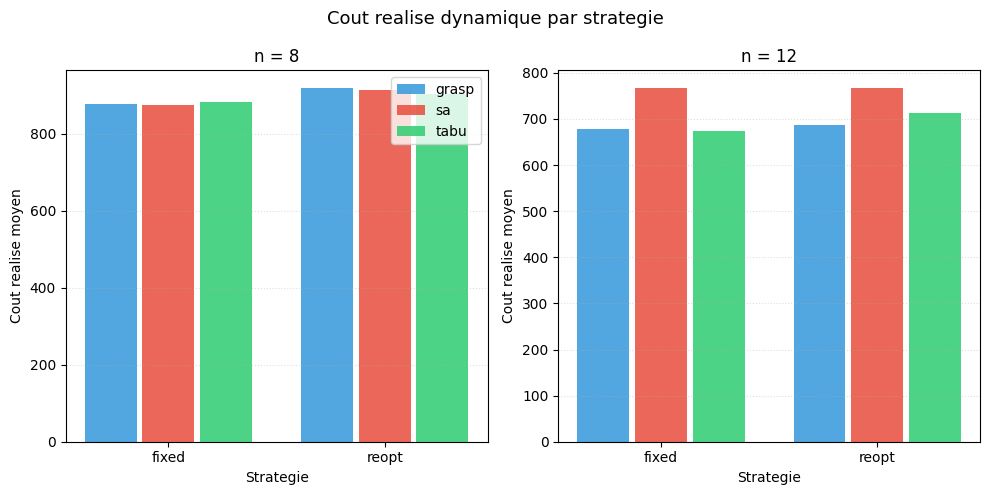

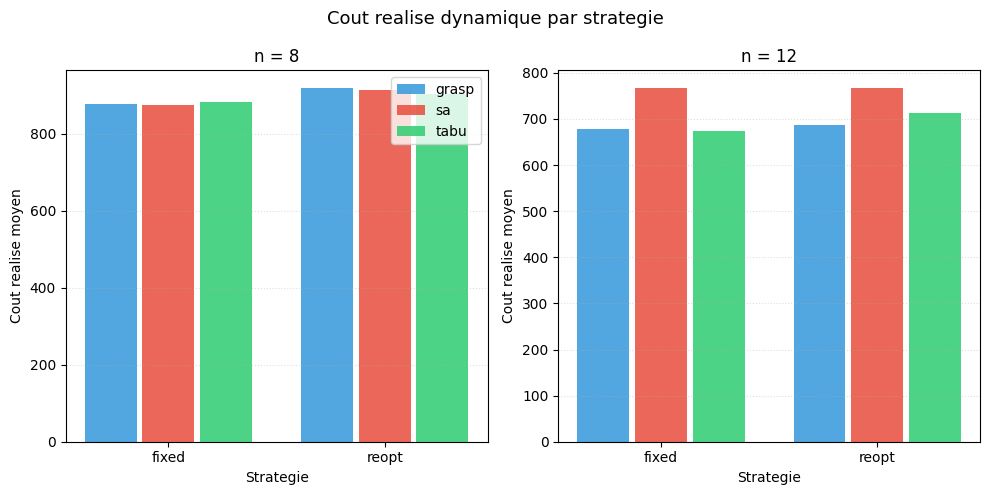

In [4]:
fig = plot_dynamic_cost_comparison(results)
fig


## 5. Figure 2 : gain relatif de la re-optimisation

`plot_dynamic_gain` trace le boxplot de

```
gain = 100 * (fixed - reopt) / fixed
```

Positif = la re-optimisation a ete payante. Un gain centre autour de 0 signifie que la strategie plan-fige est deja suffisante sur cette instance (les perturbations sont faibles ou bien tolerees). Un gain largement positif signale que la dynamique perturbe suffisamment pour justifier le cout de re-resolution.


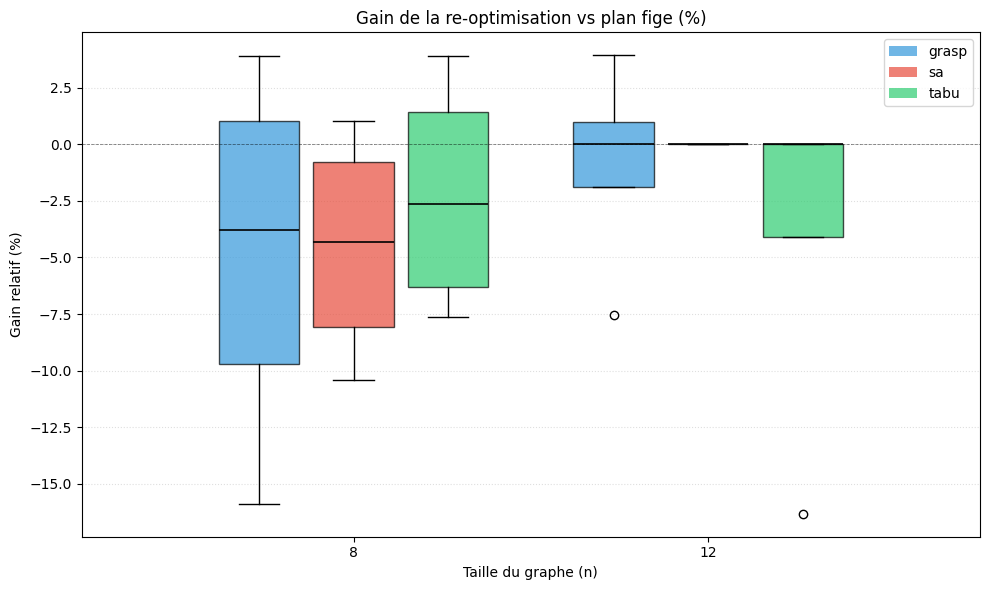

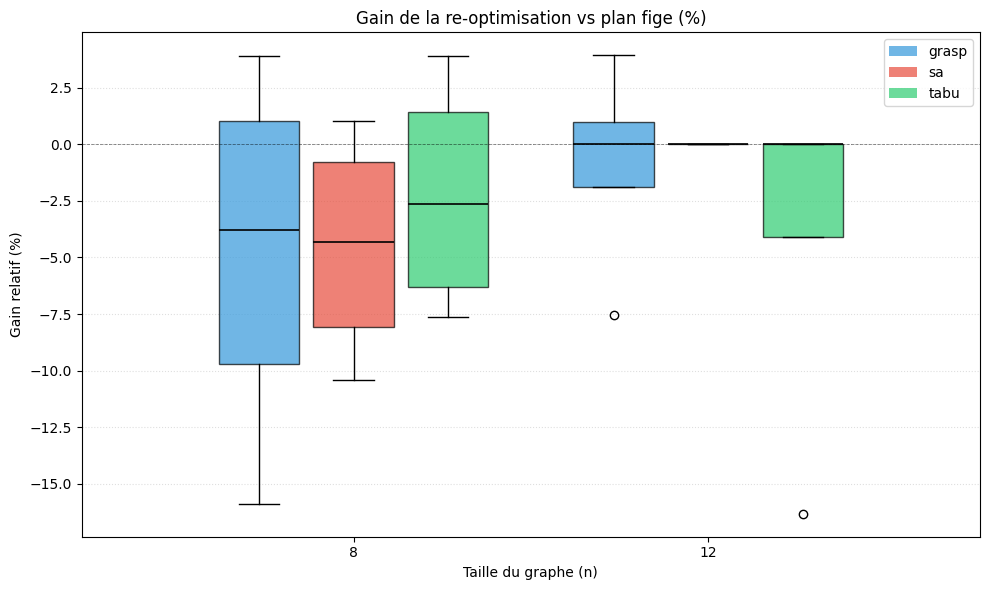

In [5]:
fig = plot_dynamic_gain(results)
fig


## 6. Figure 3 : cout planifie vs cout realise

`plot_dynamic_planned_vs_realized` : nuage de points avec la diagonale `y = x` en pointilles. Les points **au-dessus** de la diagonale indiquent que le cout reel depasse l'estimation initiale (cas general). Un algo robuste aura un nuage proche de la diagonale.


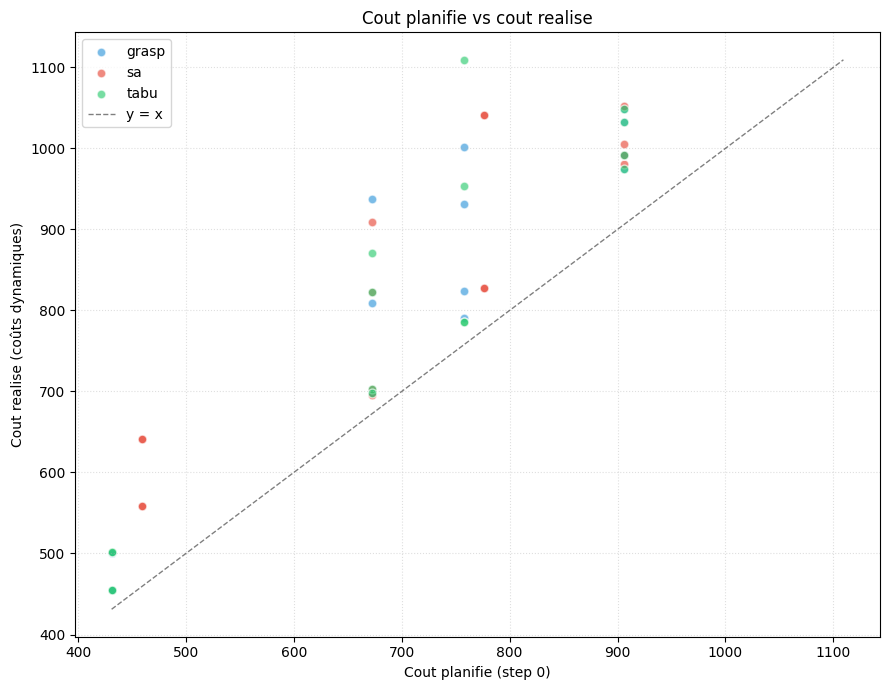

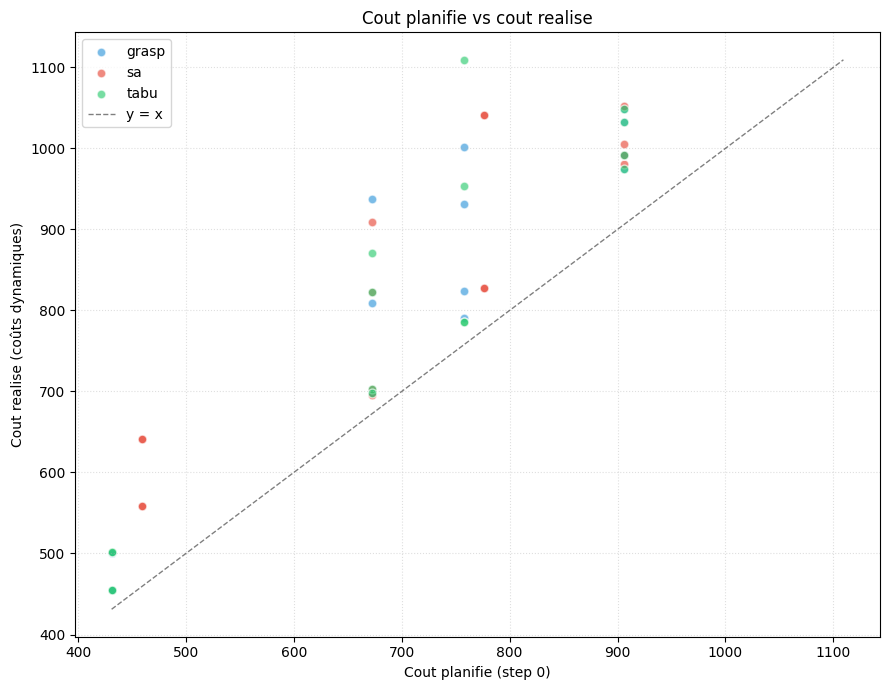

In [6]:
fig = plot_dynamic_planned_vs_realized(results)
fig


## 7. Sauvegarde des figures

`save_dynamic_benchmark_figures(results)` ecrit trois PNG (`dynamic_cost_N.png`, `dynamic_gain_N.png`, `dynamic_scatter_N.png`) dans `algorithms/image/` avec un index auto-incremente. Le dossier est dans `.gitignore` : **pas de commit de PNG**.


## 8. Conseils pour un benchmark dynamique serieux

- **Dissocier les graines**. Varier `sim_seeds` pour une meme instance isole l'effet de la dynamique de l'effet de la topologie.
- **Meme budget solveur**. Le temps `solver_time` cumule depend du nombre de reoptimisations ; pour une comparaison honnete, donner aux strategies `reopt` un budget par appel compatible.
- **Plus de repetitions sur petites tailles**. Le bruit est grand : 5 x 5 graines produit deja 25 executions par (algo, strategie).
